# Librerias

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from typing import Optional
from IPython.display import HTML, display

from pygments import highlight
from pygments.lexers import get_lexer_by_name, guess_lexer
from pygments.formatters import HtmlFormatter
from pygments.util import ClassNotFound

# Estilo

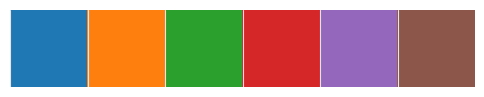

In [6]:
def apply_presentation_theme(font_family='DejaVu Sans', base_size=15, palette=None, grid=True, dpi=100):
    """
    Aplica un tema pensado para presentaciones:
      - base_size: tamaño de fuente base (ajusta todos los demás tamaños)
      - palette: lista de colores hex o nombre de paleta seaborn
      - grid: si True usa grid sutil
      - dpi: resolución de las figuras
    """
    if palette is None:
        # colores contrastantes y claros sobre fondo blanco
        palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

    sns.set_theme(style="whitegrid" if grid else "white")
    sns.set_palette(palette)

    rc = {
        "figure.dpi": dpi,
        #figsize
        "figure.figsize": (10, 8),
        "savefig.dpi": dpi,
        "figure.facecolor": "#FFFFFF",
        "axes.facecolor": "#FFFFFF",
        "axes.edgecolor": "#222222",
        "axes.linewidth": 1.0,
        "axes.titlesize": int(base_size * 1.4),
        "axes.titleweight": "bold",
        "axes.labelsize": int(base_size * 1.15),
        "xtick.labelsize": int(base_size * 1.0),
        "ytick.labelsize": int(base_size * 1.0),
        "legend.fontsize": int(base_size * 0.95),
        "legend.title_fontsize": int(base_size * 1.0),
        "font.size": base_size,
        "font.family": font_family,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.8,
        "lines.linewidth": 2,
        "lines.markersize": 8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.frameon": False,
        "text.color": "#111111",
        "axes.labelcolor": "#111111",
        "xtick.color": "#222222",
        "ytick.color": "#222222",
        #spines
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
    }

    plt.rcParams.update(rc)
def show_presentation_palette(palette=None):
    """
    Dibuja una barra con los colores de la paleta activa o la especificada.
    """
    if palette is None:
        pal = sns.color_palette()
    else:
        pal = sns.color_palette(palette)
    sns.palplot(pal)
    plt.gca().set_frame_on(False)
    plt.show()

def format_ticks_values(formato='k',vertical=False,ax=None):
    """
    Pasa variables continuas a formato K, M, G, etc."""
    from matplotlib.ticker import FuncFormatter

    def k_formatter(x, pos):
        if x >= 1_000_000_000:
            return f'{x / 1_000_000_000:.1f}G'
        elif x >= 1_000_000:
            return f'{x / 1_000_000:.1f}M'
        elif x >= 1_000:
            return f'{x / 1_000:.1f}K'
        else:
            return f'{x:.0f}'
    formatter = FuncFormatter(k_formatter)
    if vertical:
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)

# Requiere: pip install pygments
from typing import Optional
from IPython.display import HTML, display
from pygments import highlight
from pygments.lexers import get_lexer_by_name, guess_lexer
from pygments.formatters import HtmlFormatter
from pygments.util import ClassNotFound

def render_code_block(
    code: str,
    language: Optional[str] = None,
    *,
    title: Optional[str] = None,
    style: str = "monokai",
    linenos: bool = True,
    max_height: int = 460,
    font_size_px: int = 14,
    border_radius_px: int = 12,
):
    # Resolver lexer
    try:
        lexer = get_lexer_by_name(language) if language else guess_lexer(code)
    except ClassNotFound:
        lexer = get_lexer_by_name("python")

    fmt = HtmlFormatter(style=style, linenos=linenos)
    highlighted = highlight(code, lexer, fmt)
    css = fmt.get_style_defs('.highlight')

    html = f"""
    <style>
      {css}

      /* --- FIX: forzar LTR y alineación izquierda para evitar "al revés" --- */
      .codecard, .codecard * {{
        direction: ltr !important;
      }}
      .highlight, .highlight pre, .highlight code {{
        direction: ltr !important;
        unicode-bidi: embed;      /* evita reorden bi-di por números/símbolos */
        text-align: left !important;
        white-space: pre;         /* conserva espacios/indentaciones */
        font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, "Liberation Mono", "DejaVu Sans Mono", monospace;
      }}
      /* -------------------------------------------------------------------- */

      .codecard {{
        border: 1px solid #e5e7eb;
        border-radius: {border_radius_px}px;
        overflow: hidden;
        box-shadow: 0 1px 2px rgba(0,0,0,.04);
        margin: 10px 0 18px 0;
      }}
      .codecard-header {{
        background: #f8fafc;
        padding: 10px 12px;
        display: flex; justify-content: space-between; align-items: center;
        border-bottom: 1px solid #e5e7eb;
        font-family: system-ui, -apple-system, Segoe UI, Roboto, sans-serif;
        font-size: 13px; color: #374151;
      }}
      .codecard-title {{ font-weight: 600; }}
      .codecard-actions button {{
        font-size: 12px; padding: 6px 10px; border-radius: 8px;
        border: 1px solid #d1d5db; background: white; cursor: pointer;
      }}
      .codecard-body {{
        max-height: {max_height}px; overflow: auto;
        font-size: {font_size_px}px;
      }}
      .highlight pre {{ margin: 0; }}
      .highlight {{ background: #272822; }}  /* cambia a 'default' si prefieres tema claro */
    </style>

    <div class="codecard">
      <div class="codecard-header">
        <div class="codecard-title">{title or "Código"}</div>
        <div class="codecard-actions">
          <button onclick="navigator.clipboard.writeText(this.closest('.codecard').querySelector('pre').innerText)">
            Copiar
          </button>
        </div>
      </div>
      <div class="codecard-body">{highlighted}</div>
    </div>
    """
    display(HTML(html))

apply_presentation_theme()

show_presentation_palette()

# Normalizar nombres

In [7]:
df_training = pd.read_parquet(r"D:\Ciencia de Datos\7mo\Lenguaje_Natural\Proyecto\task_c\task_c_training_set_1.parquet")
df_testing = pd.read_parquet(r"D:\Ciencia de Datos\7mo\Lenguaje_Natural\Proyecto\task_c\task_c_test_set_sample.parquet")
df_validation = pd.read_parquet(r"D:\Ciencia de Datos\7mo\Lenguaje_Natural\Proyecto\task_c\task_c_validation_set.parquet")
df_training.head()

,code,generator,label,language
0,"import React, { useState, useEffect } from 're...",GPT-4o,1,JavaScript
1,<?php\n\nuse Fedeisas\LaravelJsRoutes\Commands...,Human,0,PHP
2,const math = require('mathjs');\n\n/**\n * Cal...,google/codegemma-7b-it,1,JavaScript
3,import org.junit.jupiter.params.provider.Argum...,GPT-4o,1,Java
4,// CodeForces\n\n// C. Alice and the Cake\n\n\...,Human,0,Java


In [8]:
GEN_VERBOSE = {
    #  Human
    "human": "Humano",
    "Human": "Humano",

    #  GPT (OpenAI)
    "GPT-4o": "GPT-4o",
    "GPT-4o-mini": "GPT-4o Mini",

    #  Google / Gemma / CodeGemma / Gemini
    "google/codegemma-7b": "CodeGemma 7B",
    "google/codegemma-7b-it": "CodeGemma 7B Instruct",
    "google/codegemma-2b": "CodeGemma 2B",
    "google/gemma-3-4b-it": "Gemma 3 4B Instruct",
    "google/gemma-3-12b-it": "Gemma 3 12B Instruct",
    "google/gemma-3-27b-it": "Gemma 3 27B Instruct",
    "gemma-3-27b-it": "Gemma 3 27B Instruct",
    "gemma-3n-e4b-it": "Gemma 3n E4B Instruct",
    "gemini-1.5-flash": "Gemini 1.5 Flash",
    "gemini-1.5-flash-8b": "Gemini 1.5 Flash 8B",
    "gemini-2.0-flash": "Gemini 2.0 Flash",
    "gemini-2.0-flash-lite": "Gemini 2.0 Flash Lite",
    "gemini-2.5-flash-preview-05-20": "Gemini 2.5 Flash Preview (May 2025)",

    # Qwen (Alibaba)
    "Qwen/Qwen2.5-Coder-1.5B": "Qwen 2.5 Coder 1.5B",
    "Qwen/Qwen2.5-Coder-1.5B-Instruct": "Qwen 2.5 Coder 1.5B Instruct",
    "Qwen/Qwen2.5-Coder-7B": "Qwen 2.5 Coder 7B",
    "Qwen/Qwen2.5-Coder-7B-Instruct": "Qwen 2.5 Coder 7B Instruct",
    "Qwen/Qwen2.5-Coder-14B-Instruct": "Qwen 2.5 Coder 14B Instruct",
    "Qwen/Qwen2.5-Coder-32B-Instruct": "Qwen 2.5 Coder 32B Instruct",
    "Qwen/Qwen2.5-Coder-72B-Instruct": "Qwen 2.5 Coder 72B Instruct",
    "Qwen/Qwen2.5-7B-Instruct": "Qwen 2.5 7B Instruct",
    "Qwen/Qwen3-14B": "Qwen 3 14B",
    "Qwen/Qwen3-30B-A3B": "Qwen 3 30B A3B",
    "Qwen/Qwen3-32B": "Qwen 3 32B",
    "Qwen/Qwen3-235B-A22B": "Qwen 3 235B A22B",
    "Qwen/QwQ-32B": "QwQ 32B",

    #  DeepSeek
    "deepseek-ai/deepseek-coder-1.3b-base": "DeepSeek Coder 1.3B Base",
    "deepseek-ai/deepseek-coder-1.3b-instruct": "DeepSeek Coder 1.3B Instruct",
    "deepseek-ai/deepseek-coder-6.7b-base": "DeepSeek Coder 6.7B Base",
    "deepseek-ai/deepseek-coder-6.7b-instruct": "DeepSeek Coder 6.7B Instruct",
    "deepseek-ai/DeepSeek-R1": "DeepSeek R1",
    "deepseek-ai/DeepSeek-V3-0324": "DeepSeek V3 (Mar 2024)",

    #  Mistral / Mixtral
    "mistralai/Mistral-7B-Instruct-v0.3": "Mistral 7B Instruct v0.3",
    "mistralai/Mixtral-8x7B-Instruct-v0.1": "Mixtral 8×7B Instruct v0.1",
    "mistralai/Mistral-Small-24B-Instruct-2501": "Mistral Small 24B Instruct (Jan 2025)",
    "mistralai/Mistral-Nemo-Instruct-2407": "Mistral Nemo Instruct (Jul 2024)",
    "mistralai/Devstral-Small-2505": "Devstral Small (May 2025)",

    #  Meta Llama
    "meta-llama/Llama-3.1-8B-Instruct": "Llama 3.1 8B Instruct",
    "meta-llama/Llama-3.1-8B": "Llama 3.1 8B",
    "meta-llama/Llama-3.2-1B": "Llama 3.2 1B",
    "meta-llama/Llama-3.2-3B": "Llama 3.2 3B",
    "meta-llama/Llama-3.2-11B-Vision-Instruct": "Llama 3.2 11B Vision Instruct",
    "meta-llama/Llama-3.2-90B-Vision-Instruct": "Llama 3.2 90B Vision Instruct",
    "meta-llama/Llama-3.3-70B-Instruct": "Llama 3.3 70B Instruct",
    "meta-llama/Llama-3.3-70B-Instruct-Turbo": "Llama 3.3 70B Instruct Turbo",
    "meta-llama/Meta-Llama-3.1-70B-Instruct": "Llama 3.1 70B Instruct",
    "meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo": "Llama 3.1 70B Instruct Turbo",
    "meta-llama/Meta-Llama-3.1-405B-Instruct": "Llama 3.1 405B Instruct",
    "meta-llama/Llama-4-Scout-17B-16E-Instruct": "Llama 4 Scout 17B 16E Instruct",
    "meta-llama/Llama-4-Maverick-17B-128E-Instruct-Turbo": "Llama 4 Maverick 17B 128E Turbo",
    "meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8": "Llama 4 Maverick 17B 128E FP8",

    #  CodeLlama
    "codellama/CodeLlama-70b-Instruct-hf": "CodeLlama 70B Instruct",
    "codellama/CodeLlama-34b-Instruct-hf": "CodeLlama 34B Instruct",
    "codellama/CodeLlama-7b-hf": "CodeLlama 7B",

    #  Yi Coder (01-ai)
    "01-ai/Yi-Coder-1.5B": "Yi Coder 1.5B",
    "01-ai/Yi-Coder-9B": "Yi Coder 9B",
    "01-ai/Yi-Coder-1.5B-Chat": "Yi Coder 1.5B Chat",
    "01-ai/Yi-Coder-9B-Chat": "Yi Coder 9B Chat",

    #  IBM Granite
    "ibm-granite/granite-3b-code-base-128k": "Granite 3B Code Base 128K",
    "ibm-granite/granite-3b-code-instruct-128k": "Granite 3B Code Instruct 128K",
    "ibm-granite/granite-3.2-2b-instruct": "Granite 3.2 2B Instruct",
    "ibm-granite/granite-3.3-8b-instruct": "Granite 3.3 8B Instruct",
    "ibm-granite/granite-3.3-8b-base": "Granite 3.3 8B Base",
    "ibm-granite/granite-8b-code-base-4k": "Granite 8B Code Base 4K",
    "ibm-granite/granite-8b-code-instruct-4k": "Granite 8B Code Instruct 4K",
    "ibm-granite/granite-34b-code-instruct-8k": "Granite 34B Code Instruct 8K",

    #  Microsoft Phi
    "microsoft/phi-2": "Phi-2",
    "microsoft/phi-4": "Phi-4",
    "microsoft/Phi-3-mini-4k-instruct": "Phi-3 Mini 4K Instruct",
    "microsoft/Phi-3-small-8k-instruct": "Phi-3 Small 8K Instruct",
    "microsoft/Phi-3-medium-4k-instruct": "Phi-3 Medium 4K Instruct",
    "microsoft/Phi-3.5-mini-instruct": "Phi-3.5 Mini Instruct",
    "microsoft/Phi-4-multimodal-instruct": "Phi-4 Multimodal Instruct",

    #  BigCode / StarCoder
    "bigcode/starcoder": "StarCoder",
    "bigcode/starcoderbase-1b": "StarCoder Base 1B",
    "bigcode/starcoderbase-3b": "StarCoder Base 3B",
    "bigcode/starcoder2-3b": "StarCoder2 3B",
    "bigcode/starcoder2-7b": "StarCoder2 7B",
    "bigcode/starcoder2-15b": "StarCoder2 15B",

    #  Otros
    "ibm-granite/granite-3b-code-base": "Granite 3B Code Base",
    "meta-llama/Llama-3.3-70B-Instruct": "Llama 3.3 70B Instruct",
}

In [9]:
df_training.columns = ['Codigo', 'Generador', 'Etiqueta','Lenguaje']
df_training['Generador'] = df_training['Generador'].map(GEN_VERBOSE)
df_testing.columns = ['Codigo', 'Generador', 'Etiqueta','Lenguaje']
df_testing['Generador'] = df_testing['Generador'].map(GEN_VERBOSE)
df_validation.columns = ['Codigo', 'Generador', 'Etiqueta','Lenguaje']
df_validation['Generador'] = df_validation['Generador'].map(GEN_VERBOSE)

In [10]:
df_training.head(20)

,Codigo,Generador,Etiqueta,Lenguaje
0,"import React, { useState, useEffect } from 're...",GPT-4o,1,JavaScript
1,<?php\n\nuse Fedeisas\LaravelJsRoutes\Commands...,Humano,0,PHP
2,const math = require('mathjs');\n\n/**\n * Cal...,CodeGemma 7B Instruct,1,JavaScript
3,import org.junit.jupiter.params.provider.Argum...,GPT-4o,1,Java
4,// CodeForces\n\n// C. Alice and the Cake\n\n\...,Humano,0,Java
5,"class Indexer:\n def __init__(self, token_l...",Yi Coder 9B Chat,2,Python
6,"public string Rejoin(string roomId, string use...",Humano,0,C#
7,import org.springframework.beans.factory.annot...,GPT-4o,1,Java
8,"def test_1000(self, cn_client_v2):\n """"...",Humano,0,Python
9,public void AddChild(FHeapNode<T> node)\n ...,Humano,0,C#


In [13]:
# ==========================
# CBOW por Lenguaje + Chunks
# ==========================
import os, re, numpy as np, pandas as pd
from collections import defaultdict, Counter
from scipy.sparse import csr_matrix, hstack
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

# ---------- Tokenizador ----------
_tok_id  = r"[A-Za-z_][A-Za-z0-9_]*"
_tok_ops = r"==|!=|<=|>=|->|=>|::|\+\+|--|[\(\)\{\}\[\];,\.:\+\-\*/%]"
_tok_regex = re.compile(f"{_tok_id}|{_tok_ops}")

def code_tokenizer(text: str):
    return _tok_regex.findall(text if isinstance(text, str) else "")

# ---------- Iterador por chunks ----------
class CodeSentenceIter:
    """
    Iterador que recorre df en bloques (chunks) y emite listas de tokens.
    Permite filtrar por lenguaje para entrenar modelos más pequeños.
    No carga toda la lista de oraciones a memoria.
    """
    def __init__(self, df: pd.DataFrame, lang=None, chunk_rows=20000):
        self.df = df
        self.lang = lang
        self.chunk_rows = int(chunk_rows)

    def __iter__(self):
        n = len(self.df)
        for start in range(0, n, self.chunk_rows):
            stop = min(start + self.chunk_rows, n)
            block = self.df.iloc[start:stop]
            if self.lang is not None:
                block = block[block["Lenguaje"] == self.lang]
            # Emitimos una lista de tokens por fila
            for code in block["Codigo"].astype(str):
                yield code_tokenizer(code)

# ---------- One-hot Lenguaje ----------
def ohe_language(series: pd.Series, categories=None):
    s = series.astype(str).str.strip()
    if categories is None:
        categories = sorted(s.unique())
    cat = pd.Categorical(s, categories=categories)
    ohe = pd.get_dummies(cat, drop_first=False)
    return ohe.values.astype(float), categories

# ---------- Entrenar CBOW por lenguaje ----------
def train_cbow_by_language(
    df_training: pd.DataFrame,
    vector_size=128, window=8, min_count=2, epochs=12,
    negative=5, sample=1e-3, chunk_rows=20000, seed=42
):
    from gensim.models import Word2Vec

    models = {}
    langs = sorted(df_training["Lenguaje"].astype(str).unique())

    for lang in langs:
        sentences = CodeSentenceIter(df_training, lang=lang, chunk_rows=chunk_rows)
        w2v = Word2Vec(
            vector_size=vector_size,
            window=window,
            min_count=min_count,
            workers=max(1, os.cpu_count() or 1),
            sg=0,               # CBOW
            negative=negative,
            sample=sample,
            epochs=epochs,
            seed=seed
        )
        # build_vocab y train admiten iterables reusables (nueva iteración cada llamada)
        w2v.build_vocab(corpus_iterable=sentences)
        w2v.train(
            corpus_iterable=CodeSentenceIter(df_training, lang=lang, chunk_rows=chunk_rows),
            total_examples=w2v.corpus_count, epochs=w2v.epochs
        )
        models[lang] = w2v
    return models

# ---------- IDF por lenguaje (ponderado) ----------
def fit_token_idf_by_language(df_training: pd.DataFrame):
    """Crea un TF-IDF (palabras) por lenguaje para IDF ponderado."""
    idf_by_lang = {}
    maxidf_by_lang = {}
    langs = sorted(df_training["Lenguaje"].astype(str).unique())
    for lang in langs:
        sub = df_training[df_training["Lenguaje"] == lang]
        tfidf = TfidfVectorizer(
            tokenizer=code_tokenizer, analyzer="word",
            lowercase=False, min_df=2, use_idf=True, smooth_idf=True, norm=None
        )
        tfidf.fit(sub["Codigo"])
        vocab = tfidf.get_feature_names_out()
        idf   = tfidf.idf_
        idf_by_lang[lang] = {t: w for t, w in zip(vocab, idf)}
        maxidf_by_lang[lang] = float(idf.max()) if len(idf) else 1.0
    return idf_by_lang, maxidf_by_lang

# ---------- Doc embedding (CBOW + IDF por lenguaje) ----------
def doc_embedding(tokens, w2v, idf_map, max_idf):
    vecs, weights = [], []
    for t in tokens:
        if t in w2v.wv:
            vecs.append(w2v.wv[t])
            weights.append(idf_map.get(t, max_idf))
    if vecs:
        return np.average(vecs, axis=0, weights=weights)
    return np.zeros(w2v.vector_size, dtype=float)

def embed_dataframe_by_lang(df, w2v_by_lang, idf_by_lang, maxidf_by_lang, chunk_rows=20000):
    n = len(df)
    d = next(iter(w2v_by_lang.values())).vector_size  # dim de embedding
    out = np.zeros((n, d), dtype=float)
    # procesamos por bloques para no saturar
    for start in range(0, n, chunk_rows):
        stop = min(start + chunk_rows, n)
        block = df.iloc[start:stop]
        for i, (lang, code) in enumerate(zip(block["Lenguaje"].astype(str), block["Codigo"].astype(str))):
            tokens = code_tokenizer(code)
            w2v = w2v_by_lang.get(lang)
            if w2v is None:
                # fallback: usa el primer modelo disponible
                w2v = next(iter(w2v_by_lang.values()))
                lang_for_idf = next(iter(idf_by_lang.keys()))
            else:
                lang_for_idf = lang
            idf_map  = idf_by_lang.get(lang_for_idf, {})
            max_idf  = maxidf_by_lang.get(lang_for_idf, 1.0)
            out[start + i] = doc_embedding(tokens, w2v, idf_map, max_idf)
    return out

# ---------- TF-IDF de char-ngrams (global) ----------
def fit_char_vectorizer(df_training):
    vec = TfidfVectorizer(
        analyzer="char", ngram_range=(3,6),
        min_df=2, lowercase=False
    )
    vec.fit(df_training["Codigo"])
    return vec

# ---------- Ensamble de features ----------
def transform_features_stack_chunked(df, bundle, chunk_rows=20000):
    # 1) Embeddings CBOW por lenguaje
    X_emb = embed_dataframe_by_lang(
        df,
        bundle["w2v_by_lang"],
        bundle["idf_by_lang"],
        bundle["maxidf_by_lang"],
        chunk_rows=chunk_rows
    )
    X_emb_sp = csr_matrix(X_emb)  # a sparse para apilar

    # 2) Char-ngrams global
    X_char = bundle["char_vec"].transform(df["Codigo"])

    # 3) One-hot Lenguaje con categorías fijas de training
    X_lang_dense, _ = ohe_language(df["Lenguaje"], categories=bundle["lang_categories"])
    X_lang = csr_matrix(X_lang_dense)

    # 4) Concat
    X = hstack([X_emb_sp, X_char, X_lang]).tocsr()
    return X

# ---------- Fit global (training) ----------
def fit_on_training_stack_chunked(df_training: pd.DataFrame, chunk_rows=20000):
    assert {"Codigo","Lenguaje","Etiqueta"}.issubset(df_training.columns)
    y_train = df_training["Etiqueta"].astype(int)

    # CBOW por lenguaje (streaming)
    w2v_by_lang = train_cbow_by_language(
        df_training,
        vector_size=128, window=8, min_count=2, epochs=12,
        negative=5, sample=1e-3, chunk_rows=chunk_rows
    )

    # IDF por lenguaje (para ponderar)
    idf_by_lang, maxidf_by_lang = fit_token_idf_by_language(df_training)

    # Char-ngrams global
    char_vec = fit_char_vectorizer(df_training)

    # Categorías de lenguaje
    _, lang_categories = ohe_language(df_training["Lenguaje"], categories=None)

    # Construir X_train en chunks
    X_train = transform_features_stack_chunked(
        df_training,
        {
            "w2v_by_lang": w2v_by_lang,
            "idf_by_lang": idf_by_lang,
            "maxidf_by_lang": maxidf_by_lang,
            "char_vec": char_vec,
            "lang_categories": lang_categories
        },
        chunk_rows=chunk_rows
    )

    # Clasificador
    clf = LogisticRegression(
        solver="saga",
        penalty="l2",
        C=1.0,
        max_iter=5000,
        class_weight="balanced",
        n_jobs=-1,
        multi_class="multinomial",
        random_state=42
    )
    clf.fit(X_train, y_train)

    bundle = {
        "w2v_by_lang": w2v_by_lang,
        "idf_by_lang": idf_by_lang,
        "maxidf_by_lang": maxidf_by_lang,
        "char_vec": char_vec,
        "lang_categories": lang_categories,
        "clf": clf
    }
    return bundle

# ---------- Evaluación ----------
def evaluate_on(df, bundle, name="set", chunk_rows=20000):
    y_true = df["Etiqueta"].astype(int)
    X = transform_features_stack_chunked(df, bundle, chunk_rows=chunk_rows)
    y_pred = bundle["clf"].predict(X)
    f1 = f1_score(y_true, y_pred, average="macro")
    print(f"\n[{name}] F1 macro: {f1:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    print("Matriz de confusión (filas=verdad, cols=pred): labels=[0(human),1(machine),2(hybrid),3(adversarial)]")
    print(confusion_matrix(y_true, y_pred, labels=[0,1,2,3]))

# ======== USO ========
# bundle = fit_on_training_stack_chunked(df_training, chunk_rows=20000)
# evaluate_on(df_validation, bundle, name="validation", chunk_rows=20000)
# evaluate_on(df_test, bundle, name="test", chunk_rows=20000)
